In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## Import Data

In [216]:
base_path = Path(r"C:\Users\morit\Documents\A_Uni\Notes\DS5\Tryout\modelT\results_test\barcelona")
fold = 1

In [217]:
fold_path = base_path / f"Fold_{fold}"
patches_img = np.load(fold_path / "images.npy")
patches_pred = np.load(fold_path / "predictions.npy")
patches_targ = np.load(fold_path / "targets.npy")
patches_prob = np.load(fold_path / "probabilities.npy")

In [218]:
print(f"Image shape: {patches_img.shape}\nPrediction shape: {patches_pred.shape}\nTargets shape: {patches_targ.shape}\nProbabilities shape: {patches_prob.shape}")

Image shape: (90, 3, 5, 256, 256)
Prediction shape: (90, 1, 256, 256)
Targets shape: (90, 1, 256, 256)
Probabilities shape: (90, 1, 256, 256)


## Display Images

In [221]:
# select image number (must be smaller then first dim of input arrays)
img_number = 55

# month must be smaller then second dim of image shape)
month = 1

In [222]:
# getting the right patches and transposing them to get final visualizations
img = np.transpose(patches_img[img_number][month][:3], (1, 2, 0))
img_nir = patches_img[img_number][month][4]
pred = patches_pred[img_number][0]
patches_pred_bins = np.floor(patches_pred + 0.5)
pred_bin = patches_pred_bins[img_number][0]
targ = patches_targ[img_number][0]
prob = patches_prob[img_number][0]
count = pred/prob

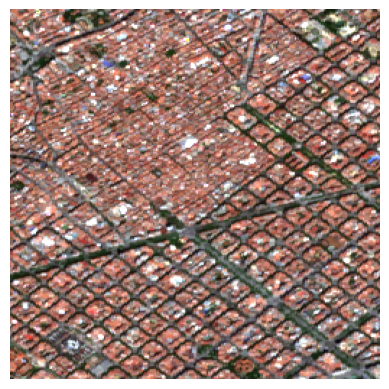

In [223]:
# plot the image
plt.imshow(img)
plt.axis("off")
plt.show()

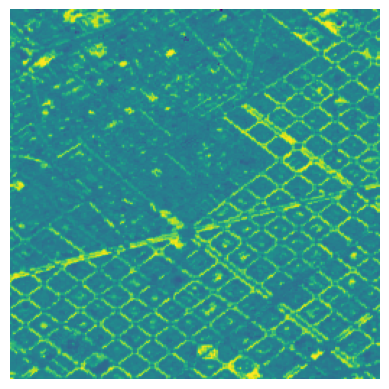

In [224]:
# plot NIR
plt.imshow(img_nir)
plt.axis("off")
plt.show()

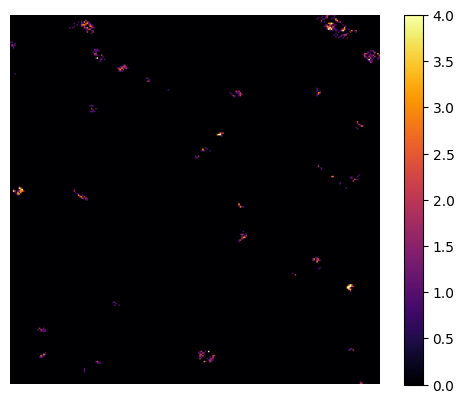

In [225]:
# plot the target
plt.imshow(targ, cmap='inferno',vmin=0,vmax=4)
plt.colorbar()
plt.axis("off")
plt.show()

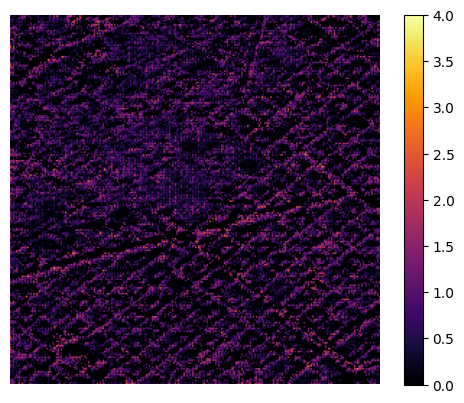

In [226]:
# plot final predictions
plt.imshow(pred, cmap='inferno',vmin=0,vmax=4)
plt.colorbar()
plt.axis("off")
plt.show()

In [227]:
pred.sum()

np.float32(26714.938)

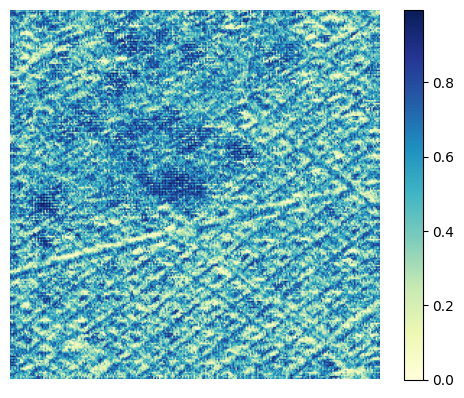

In [228]:
# plot the predicted probability
plt.imshow(prob, cmap='YlGnBu', vmin=0)
plt.colorbar()
plt.axis("off")
plt.show()

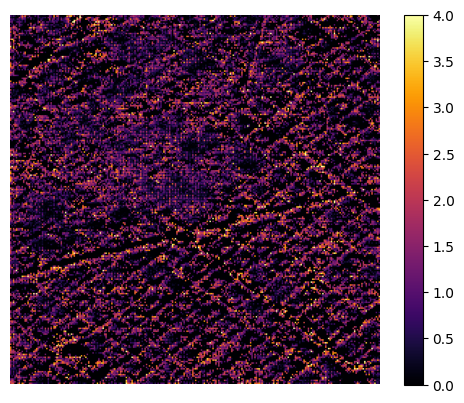

In [229]:
# plot the predicted counts
plt.imshow(count, cmap='inferno',vmin=0,vmax=4)
plt.colorbar()
plt.axis("off")
plt.show()

In [230]:
# get the patch with the most trees in the target
max_patch_id = 0
max_trees = 0
for patch_id, patch in enumerate(patches_targ):
    if np.sum(patch) > max_trees:
        max_patch_id = patch_id
        max_trees = np.sum(patch)

In [231]:
max_patch_id

17